In [12]:
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [13]:
path_cwd = pathlib.Path.cwd()
input_dataset_path = pathlib.Path(path_cwd,"..", "data_processed", "df_final.csv")
df_final = pd.read_csv(input_dataset_path)

In [14]:
df_final.head()

,REF_AREA,DATA_TYPE,TIME_PERIOD,OBS_VALUE,Codice Comune (numerico),Comune,Popolazione residente,Superficie (Kmq),Road_accident_per_resident,Road_accident_per_Kmq,Densità_della_popolazione
0,1001,ROADACC,2001,5,1001.0,Agliè,2545.0,13.1462,0.001965,0.380338,193.592065
1,1001,ROADACC,2002,5,1001.0,Agliè,2545.0,13.1462,0.001965,0.380338,193.592065
2,1001,ROADACC,2003,4,1001.0,Agliè,2545.0,13.1462,0.001572,0.304270,193.592065
3,1001,ROADACC,2004,9,1001.0,Agliè,2545.0,13.1462,0.003536,0.684608,193.592065
4,1001,ROADACC,2005,2,1001.0,Agliè,2545.0,13.1462,0.000786,0.152135,193.592065


In [15]:
input_dataframe = df_final[
    [
        'Densità_della_popolazione',
        'Road_accident_per_Kmq'
    ]
]

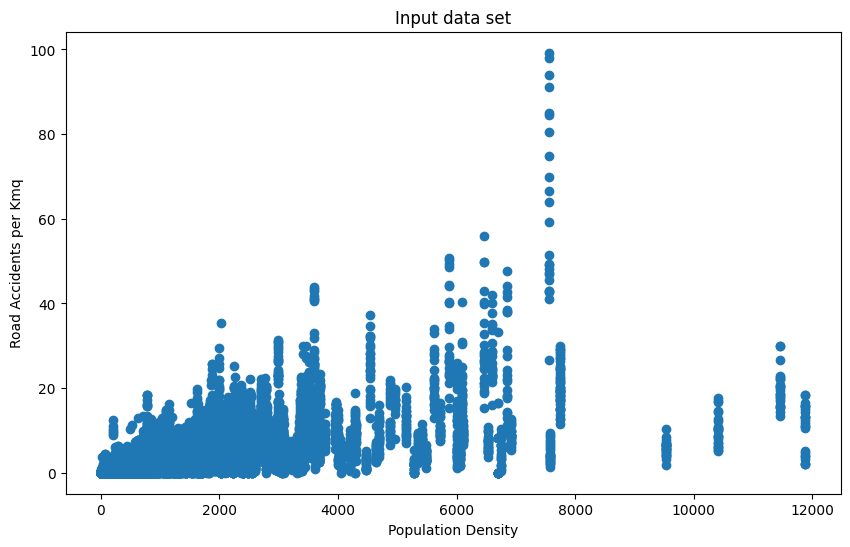

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df_final["Densità_della_popolazione"], df_final["Road_accident_per_Kmq"], marker="o")
plt.title('Input data set')
plt.xlabel('Population Density')
plt.ylabel('Road Accidents per Kmq')

# Show the plot
plt.show()

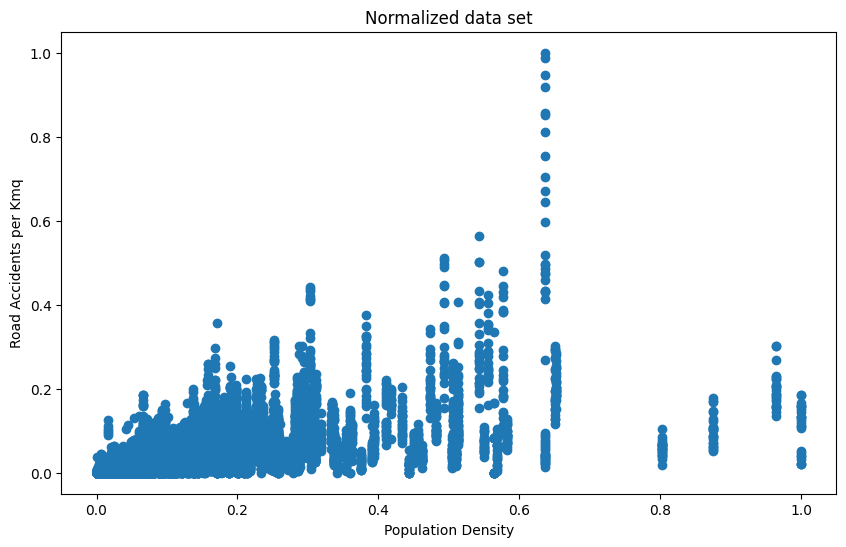

In [17]:
scale_norm = MinMaxScaler()
scaled_dataframe = pd.DataFrame(
    scale_norm.fit_transform(input_dataframe),
    columns=input_dataframe.columns)

plt.figure(figsize=(10, 6))
plt.scatter(
    scaled_dataframe["Densità_della_popolazione"], scaled_dataframe["Road_accident_per_Kmq"], marker="o")
plt.title('Normalized data set')
plt.xlabel('Population Density')
plt.ylabel('Road Accidents per Kmq')

plt.show()

In [18]:
scaled_dataframe.head() 
scaled_dataframe.dtypes

Densità_della_popolazione    float64
Road_accident_per_Kmq        float64
dtype: object

In [19]:
scaled_dataframe.isnull().sum()

Densità_della_popolazione    0
Road_accident_per_Kmq        0
dtype: int64

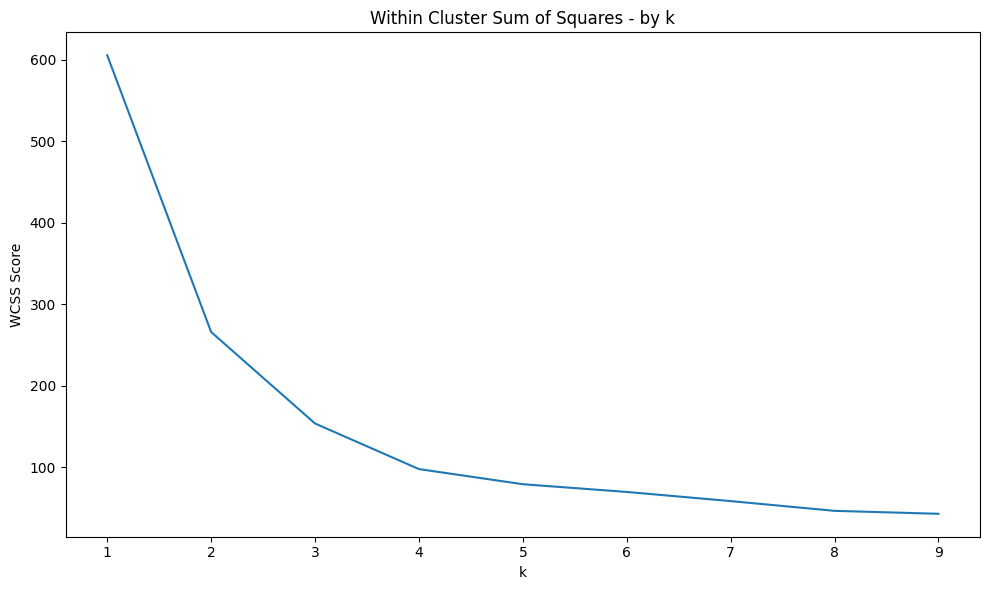

In [20]:
# Use WCSS to find a good value k
k_values = list(range(1, 10))
wcss_list = []

for k in k_values:
	kmeans = KMeans(n_clusters=k, random_state=42)
	kmeans.fit(scaled_dataframe)
	wcss_list.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss_list)
plt.title("Within Cluster Sum of Squares - by k")
plt.xlabel("k")
plt.ylabel("WCSS Score")
plt.tight_layout()
plt.show()

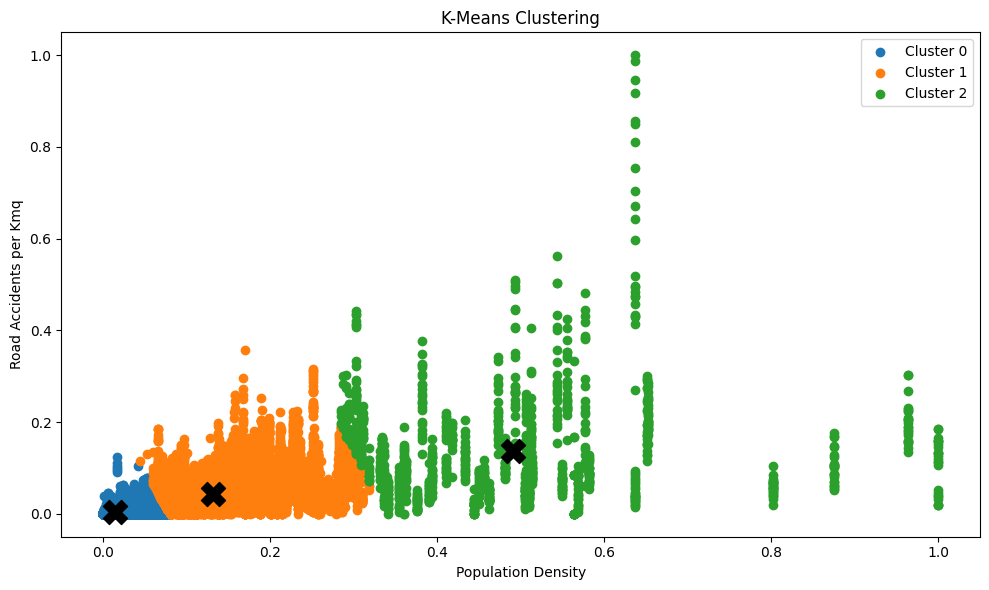

In [21]:
k = 3  # Set the number of clusters based on the elbow method
# Instantiate and fit the KMeans model
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(
    scaled_dataframe[["Densità_della_popolazione", "Road_accident_per_Kmq"]])

# Add the cluster labels to the DataFrame
scaled_dataframe["cluster"] = kmeans.labels_

# Plot the clusters and centroids
centroids = kmeans.cluster_centers_
clusters = scaled_dataframe.groupby("cluster")
plt.figure(figsize=(10, 6))
for cluster, data in clusters:
    plt.scatter(
        data["Densità_della_popolazione"], data["Road_accident_per_Kmq"], marker="o", label=f'Cluster {cluster}')
    plt.scatter(
        centroids[cluster, 0], centroids[cluster, 1], marker="X", color="black", s=300)

plt.xlabel("Population Density")
plt.ylabel("Road Accidents per Kmq")
plt.title("K-Means Clustering")
plt.legend()
plt.tight_layout()
plt.show()